In [34]:
import numpy as np
import pandas as pd

In [35]:
df = pd.read_csv('/content/Dataset .csv')

In [36]:
print(df[['Latitude', 'Longitude']].head())
print(df[['Latitude', 'Longitude']].dtypes)

    Latitude   Longitude
0  14.565443  121.027535
1  14.553708  121.014101
2  14.581404  121.056831
3  14.585318  121.056475
4  14.584450  121.057508
Latitude     float64
Longitude    float64
dtype: object


In [37]:
print(df["Latitude"].mean(), df["Longitude"].mean())

25.854380700074756 64.12657446168706


In [38]:
import folium
from folium.plugins import MarkerCluster

map_restaurants = folium.Map(location=[df["Latitude"].mean(), df["Longitude"].mean()], zoom_start=12)
# map_restaurants = folium.Map(location=[18.5204, 73.8567], zoom_start=12)

marker_cluster = MarkerCluster().add_to(map_restaurants)

count = 0
for idx, row in df.iterrows():
    if pd.notnull(row["Latitude"]) and pd.notnull(row["Longitude"]):
        count += 1
        folium.Marker(
            location=[row["Latitude"], row["Longitude"]],
            popup=f"{row['Restaurant Name']}<br>{row['City']}",
            tooltip=row["Restaurant Name"]
        ).add_to(marker_cluster)


print(f"Markers added: {count}")


map_restaurants.save("restaurant_map.html")

Markers added: 9551


##Geographical Analysis

In [39]:
#Restaurant Count by City
city_counts = df["City"].value_counts()
print(city_counts)

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
                  ... 
Lakes Entrance       1
Mohali               1
Panchkula            1
Bandung              1
Randburg             1
Name: count, Length: 141, dtype: int64


In [40]:
# Average Rating by City
avg_rating_city = df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False)
print(avg_rating_city)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
                      ...   
New Delhi           2.438845
Montville           2.400000
Mc Millan           2.400000
Noida               2.036204
Faridabad           1.866932
Name: Aggregate rating, Length: 141, dtype: float64


In [41]:
# Average Price Range by City
avg_price_city = df.groupby("City")["Price range"].mean().sort_values(ascending=False)
print(avg_price_city)

City
Panchkula           4.0
Vineland Station    4.0
Paynesville         4.0
Johannesburg        4.0
Inner City          4.0
                   ... 
Fernley             1.0
Dicky Beach         1.0
Miller              1.0
Mc Millan           1.0
Vernonia            1.0
Name: Price range, Length: 141, dtype: float64


In [42]:
#Top Cuisines by City
df_exploded = df.copy()
df_exploded["Cuisines"] = df_exploded["Cuisines"].str.split(", ")
df_exploded = df_exploded.explode("Cuisines")

top_cuisines_city = df_exploded.groupby("City")["Cuisines"].value_counts().groupby(level=0).nlargest(3)
print(top_cuisines_city)

City            City            Cuisines       
Abu Dhabi       Abu Dhabi       Indian              7
                                American            4
                                Chinese             3
Agra            Agra            North Indian       15
                                Mughlai             9
                                                   ..
Winchester Bay  Winchester Bay  Steak               1
Yorkton         Yorkton         Asian               1
��stanbul       ��stanbul       Cafe                4
                                Desserts            4
                                Restaurant Cafe     4
Name: count, Length: 375, dtype: int64


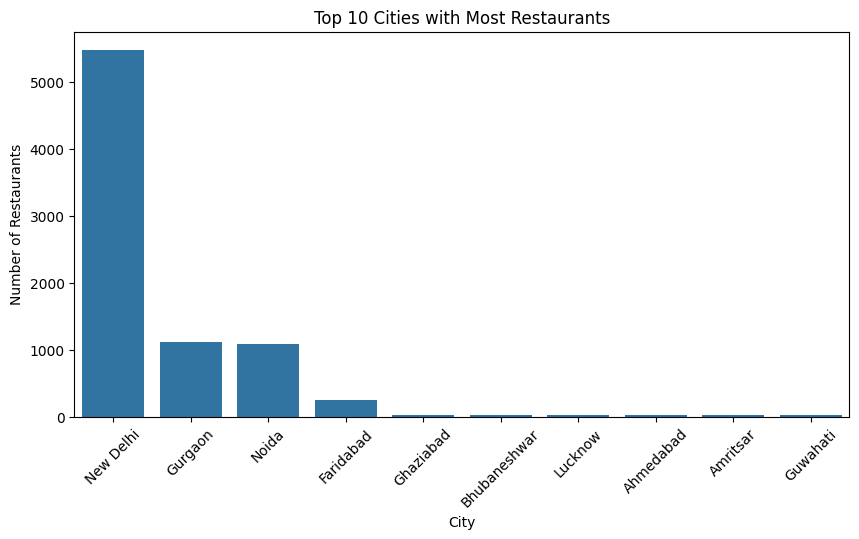

In [43]:
# Top 10 Cities with Most Restaurants
import matplotlib.pyplot as plt
import seaborn as sns

top_cities = city_counts.head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_cities.index, y=top_cities.values)
plt.title("Top 10 Cities with Most Restaurants")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

##Insights

Top Cities with Highest Avg Rating:
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64


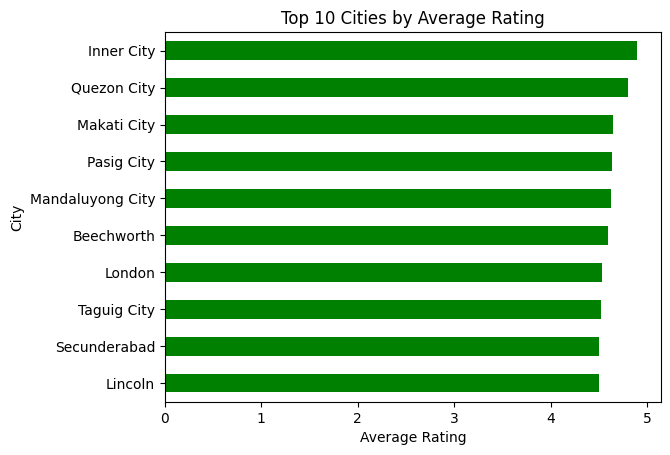

In [44]:
# Cities with Highest Average Ratings
top_rated_cities = df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False).head(10)

print("Top Cities with Highest Avg Rating:")
print(top_rated_cities)

top_rated_cities.plot(kind='barh', color='green')
plt.xlabel("Average Rating")
plt.title("Top 10 Cities by Average Rating")
plt.gca().invert_yaxis()
plt.show()

 Expensive Cities:
City
Panchkula           4.000000
Vineland Station    4.000000
Paynesville         4.000000
Johannesburg        4.000000
Inner City          4.000000
Pasay City          4.000000
Princeton           4.000000
Sandton             3.818182
Mandaluyong City    3.750000
Pretoria            3.700000
Name: Price range, dtype: float64
\ Cheapest Cities:
City
Clatskanie        1.0
Inverloch         1.0
Fernley           1.0
Dicky Beach       1.0
Miller            1.0
Mc Millan         1.0
Lakeview          1.0
Lakes Entrance    1.0
Vernonia          1.0
Dalton            1.4
Name: Price range, dtype: float64


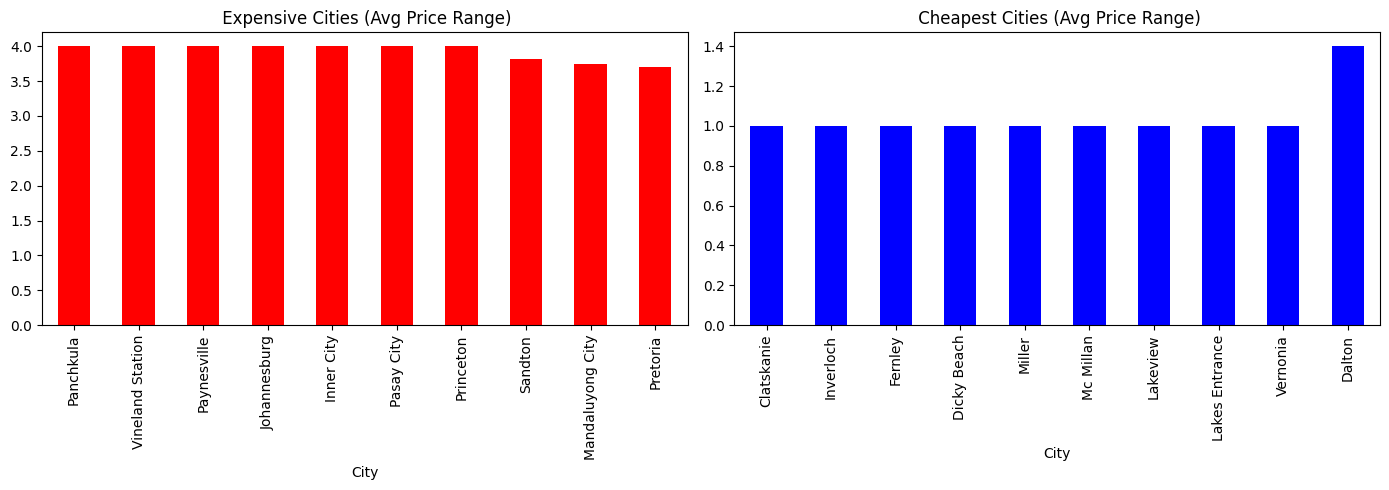

In [45]:
# Cities with Most Expensive / Cheapest Price Ranges

expensive = df.groupby("City")["Price range"].mean().sort_values(ascending=False).head(10)
cheap = df.groupby("City")["Price range"].mean().sort_values().head(10)
print(" Expensive Cities:")
print(expensive)
print("\ Cheapest Cities:")
print(cheap)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
expensive.plot(kind='bar', ax=ax[0], color='red', title=" Expensive Cities (Avg Price Range)")
cheap.plot(kind='bar', ax=ax[1], color='blue', title=" Cheapest Cities (Avg Price Range)")
plt.tight_layout()
plt.show()

In [46]:
# Which Cuisine Dominates Each City
df_cuisine = df.copy()
df_cuisine["Cuisines"] = df_cuisine["Cuisines"].str.split(", ")
df_cuisine = df_cuisine.explode("Cuisines")

df_cuisine = df_cuisine.dropna(subset=["Cuisines"])

dominant = df_cuisine.groupby("City")["Cuisines"].agg(lambda x: x.value_counts().idxmax())

print("Dominant Cuisine per City:")
print(dominant)

Dominant Cuisine per City:
City
Abu Dhabi                Indian
Agra               North Indian
Ahmedabad           Continental
Albany                 American
Allahabad          North Indian
                       ...     
Weirton                  Burger
Wellington City            Cafe
Winchester Bay           Burger
Yorkton                   Asian
��stanbul              Desserts
Name: Cuisines, Length: 140, dtype: object


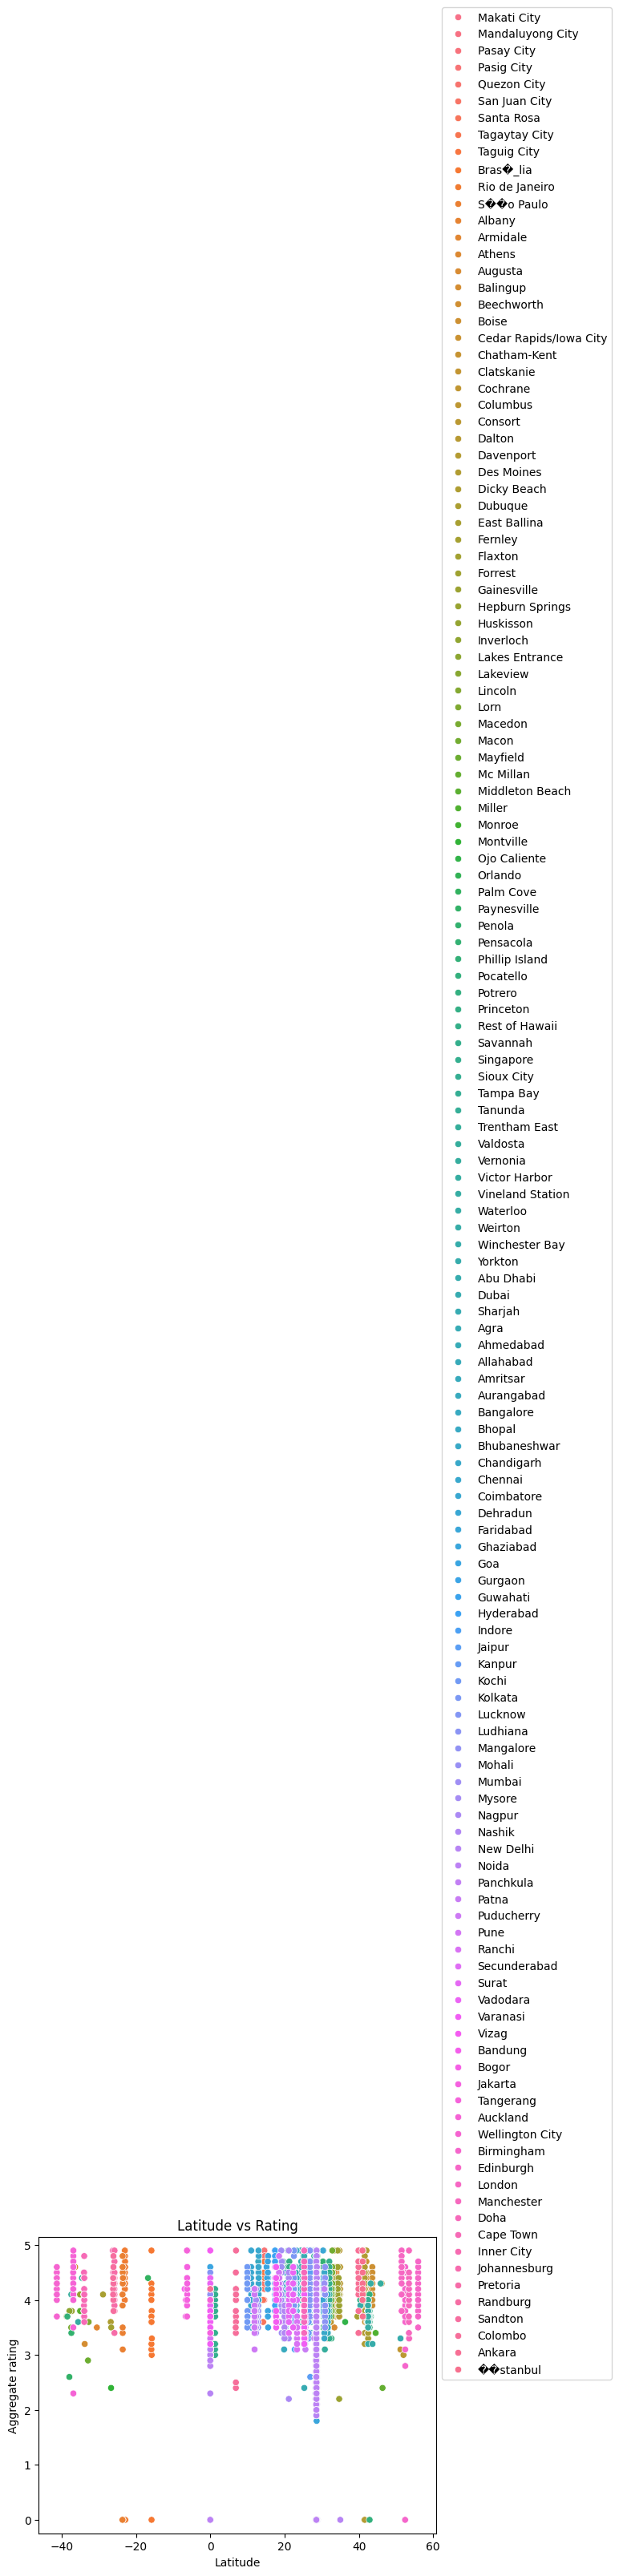

In [47]:
# Latitude vs Rating
sns.scatterplot(data=df, x="Latitude", y="Aggregate rating", hue="City")
plt.title("Latitude vs Rating")
plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
plt.show()

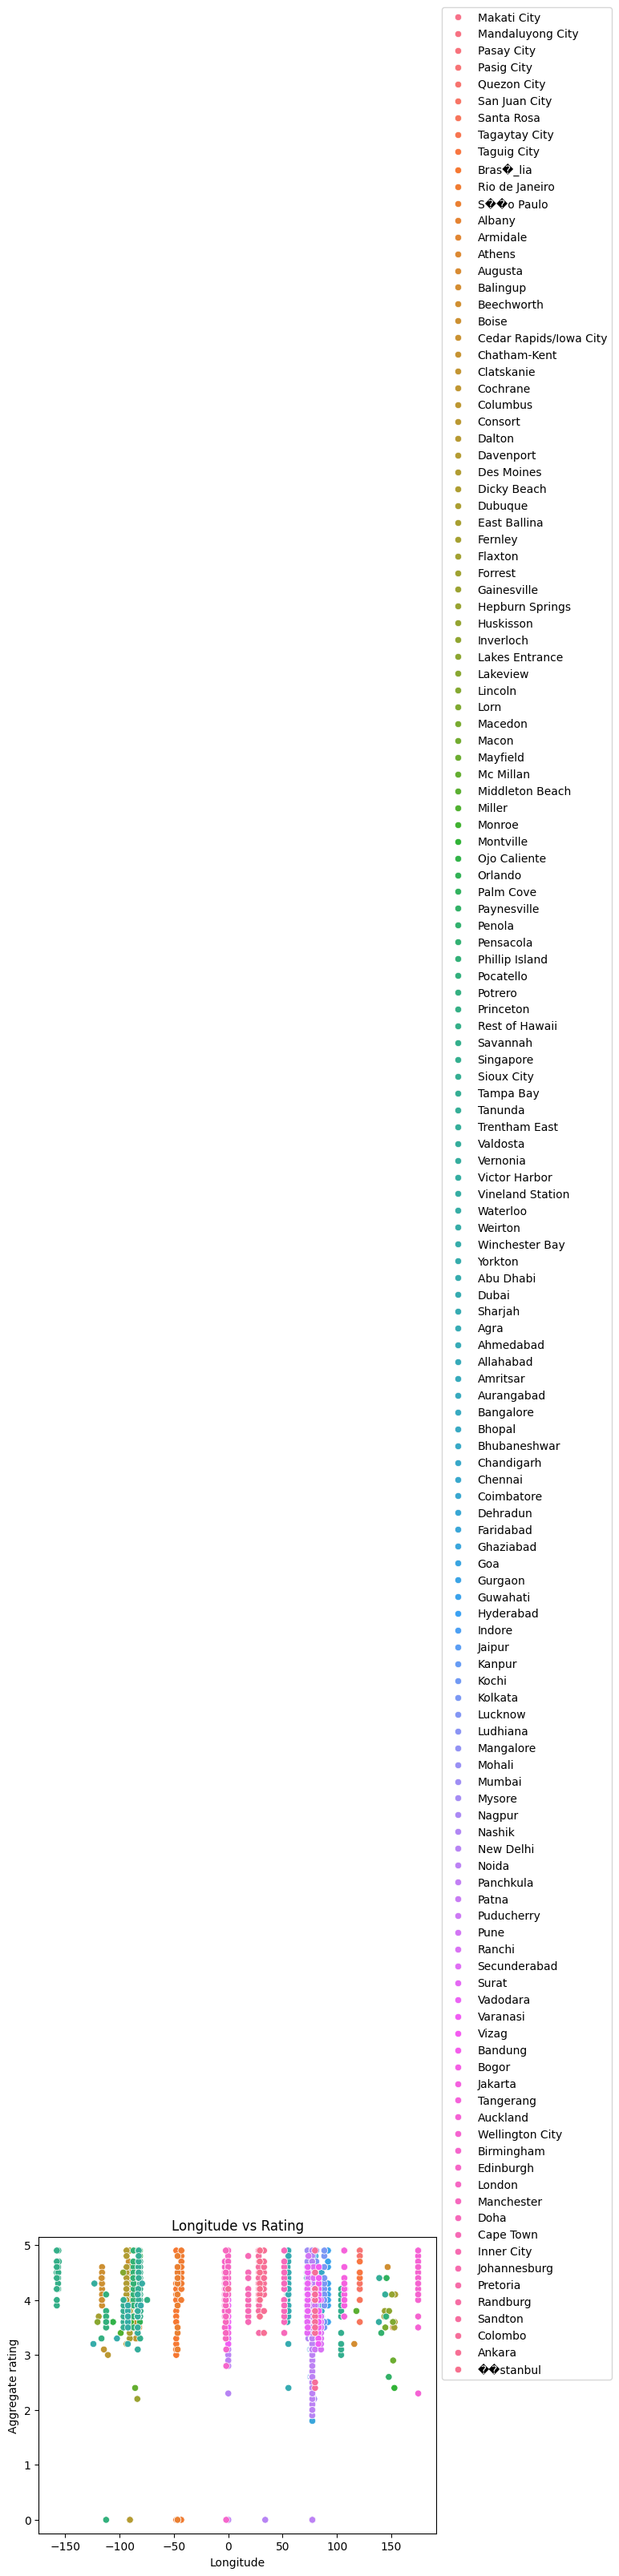

In [48]:
# Longitude vs Rating
sns.scatterplot(data=df, x="Longitude", y="Aggregate rating", hue="City")
plt.title("Longitude vs Rating")
plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
plt.show()